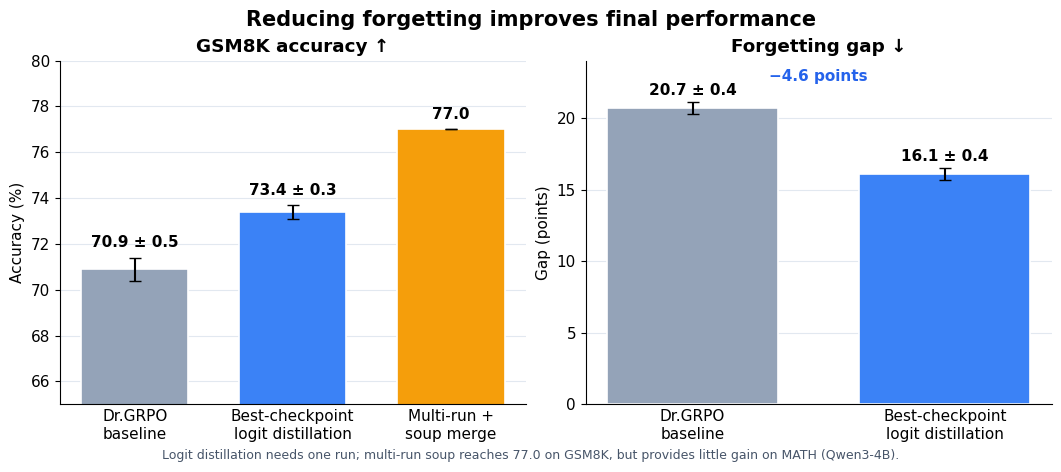

Saved to /Users/fangyuanyu/Implementation/arl/asset/w5_method_comparison.png


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

methods = ["Dr.GRPO\nbaseline", "Best-checkpoint\nlogit distillation", "Multi-run +\nsoup merge"]
accuracy = np.array([70.9, 73.4, 77.0])
accuracy_err = np.array([0.5, 0.3, 0.0])
gap = np.array([20.7, 16.1])
gap_err = np.array([0.4, 0.4])
colors = ["#94A3B8", "#3B82F6", "#F59E0B"]

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4), constrained_layout=True)

# Aggregate means require bars with error bars, not a histogram.
x = np.arange(len(methods))
axes[0].bar(x, accuracy, yerr=accuracy_err, color=colors, width=0.68,
            capsize=4, edgecolor="white", linewidth=1.2)
axes[0].set(title="GSM8K accuracy ↑", ylabel="Accuracy (%)", xticks=x,
            xticklabels=methods, ylim=(65, 80))
for i, (value, error) in enumerate(zip(accuracy, accuracy_err)):
    suffix = f" ± {error:.1f}" if error else ""
    axes[0].text(i, value + error + 0.45, f"{value:.1f}{suffix}",
                 ha="center", fontweight="bold")

x_gap = np.arange(2)
axes[1].bar(x_gap, gap, yerr=gap_err, color=colors[:2], width=0.68,
            capsize=4, edgecolor="white", linewidth=1.2)
axes[1].set(title="Forgetting gap ↓", ylabel="Gap (points)", xticks=x_gap,
            xticklabels=methods[:2], ylim=(0, 24))
for i, (value, error) in enumerate(zip(gap, gap_err)):
    axes[1].text(i, value + error + 0.5, f"{value:.1f} ± {error:.1f}",
                 ha="center", fontweight="bold")
axes[1].text(0.5, 0.94, "−4.6 points", transform=axes[1].transAxes,
             ha="center", color="#2563EB", fontweight="bold")

for ax in axes:
    ax.grid(axis="y", color="#E2E8F0", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", length=0)

fig.suptitle("Reducing forgetting improves final performance", fontsize=15,
             fontweight="bold")
fig.text(0.5, -0.03,
         "Logit distillation needs one run; multi-run soup reaches 77.0 on GSM8K, "
         "but provides little gain on MATH (Qwen3-4B).",
         ha="center", color="#475569", fontsize=9)

root = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
out = root / "asset" / "w5_method_comparison.png"
fig.savefig(out, dpi=220, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved to {out}")

In [ ]:
# What doesn't work
# (1). Token level distillation doesn't work
# replay 'forgettable' queries in every GRPO group: 71.3% -> 68.9%
# combine GRPO objective with SFT on 'forgettable queries' -> 71.3% -> 15.5% (CoT disappears, length collapse, here we pick the shortest rollouts from pass@8 for SFT)

# SFT on multiple intermediate checkpoints' greedy rollout degrades validation accuracy from base model. (do you still got data points to back up this claim?)



In [2]:
from IPython.display import Image, display

from src.churn_distill_animation import make_churn_distill_animation

root = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
gif_path = root / "asset" / "w5_churn_to_distillation.gif"
make_churn_distill_animation(
    root / "output" / "forget_gap",
    gif_path,
    fps=2,
)
plt.close()
display(Image(filename=gif_path))

ModuleNotFoundError: No module named 'src.churn_distill_animation'